In [16]:
import torch
import ultralytics
print(f"✅ PyTorch: {torch.__version__}")
print(f"✅ Ultralytics: {ultralytics.__version__}")
import torch.serialization
from ultralytics.nn.tasks import DetectionModel
try:
    torch.serialization.add_safe_globals([DetectionModel])
    print("The security global variable has been set successfully.")
except Exception as e:
    print(f"Warning for setting security global variables: {e}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ PyTorch: 2.9.1+cu128
✅ Ultralytics: 8.3.228
The security global variable has been set successfully.


In [17]:
import os
import sys
sys.path.append('/content')

from config import config
from data_loader import DataLoader
from model import MobileNetFeatureYOLOv8
from trainer import PestTrainer
from evaluator import ModelEvaluator
from utils import set_seed, plot_sample_images, print_system_info
from augmentations import visualize_augmentations

In [18]:
set_seed(42)
print_system_info()

PyTorch: 2.9.1+cu128
CUDA: True
GPU: Tesla T4
device: cuda


In [19]:
print("Downloading AgroPest-12 data set")
from google.colab import files
import zipfile

print("kaggle.json：")

try:
    !mkdir -p ~/.kaggle

    uploaded = files.upload()
    for filename in uploaded.keys():
      if filename == 'kaggle.json':
        !cp kaggle.json ~/.kaggle/
        !chmod 600 ~/.kaggle/kaggle.json
    !kaggle datasets download -d rupankarmajumdar/crop-pests-dataset
    !unzip -q crop-pests-dataset.zip -d AgroPest-12/
    print("The dataset download and extraction have been completed.")

except Exception as e:
    print(f"Kaggle API failed: {e}")

kaggle.json：


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/rupankarmajumdar/crop-pests-dataset
License(s): MIT
 98% 527M/537M [00:03<00:00, 92.9MB/s]
100% 537M/537M [00:03<00:00, 174MB/s] 
The dataset download and extraction have been completed.


In [20]:
print("Verify the structure of the data set.")
data_loader = DataLoader(config)
data_path = config.DATASET_PATH

if data_loader.verify_dataset(data_path):
    print("The structure of the dataset is correct.")
else:
    print("fail")
    !find AgroPest-12 -type d | sort

Verify the structure of the data set.
Verify the structure of the data set
find: AgroPest-12/train/images
find: AgroPest-12/train/labels
find: AgroPest-12/valid/images
find: AgroPest-12/valid/labels
find: AgroPest-12/test/images
find: AgroPest-12/test/labels
📊 train: 11502 images, 11502 labels
  match: 11502 pairs, unmatched images: 0, unmatched labels: 0
📊 valid: 1095 images, 1095 labels
  match: 1095 pairs, unmatched images: 0, unmatched labels: 0
📊 test: 546 images, 546 labels
  match: 546 pairs, unmatched images: 0, unmatched labels: 0
The structure of the dataset is correct.


In [21]:
print("YOLO")
data_yaml_path = data_loader.prepare_data_yaml(data_path)
print(f"✅ data.yaml: {data_yaml_path}")

YOLO
data.yaml: AgroPest-12/data.yaml
✅ data.yaml: AgroPest-12/data.yaml


In [22]:
print("Statistical information of the dataset:")
train_images_dir = os.path.join(data_path, 'train/images')
val_images_dir = os.path.join(data_path, 'valid/images')
test_images_dir = os.path.join(data_path, 'test/images')

train_count = len([f for f in os.listdir(train_images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
val_count = len([f for f in os.listdir(val_images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])
test_count = len([f for f in os.listdir(test_images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))])

print(f"train set: {train_count}")
print(f"validation set: {val_count}")
print(f"test set: {test_count}")

Statistical information of the dataset:
train set: 11502
validation set: 1095
test set: 546


sample images


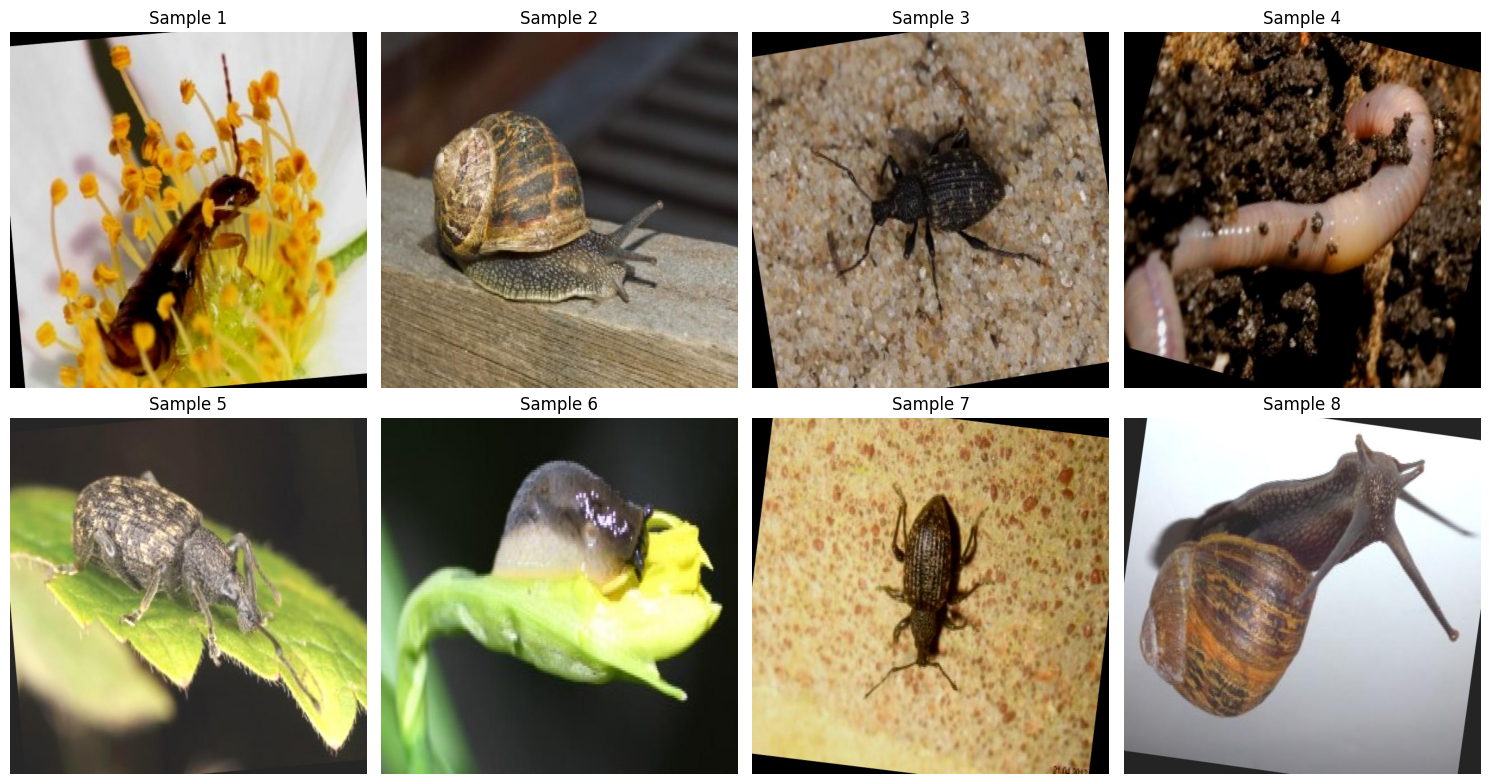

In [23]:
print("sample images")
plot_sample_images(data_path)

data enhancement
Visualizing the effect of data augmentation: catterpillar-373-_jpg.rf.20375d0addbfae311e3d1b440232ad1f.jpg
Number of bounding boxes: 1


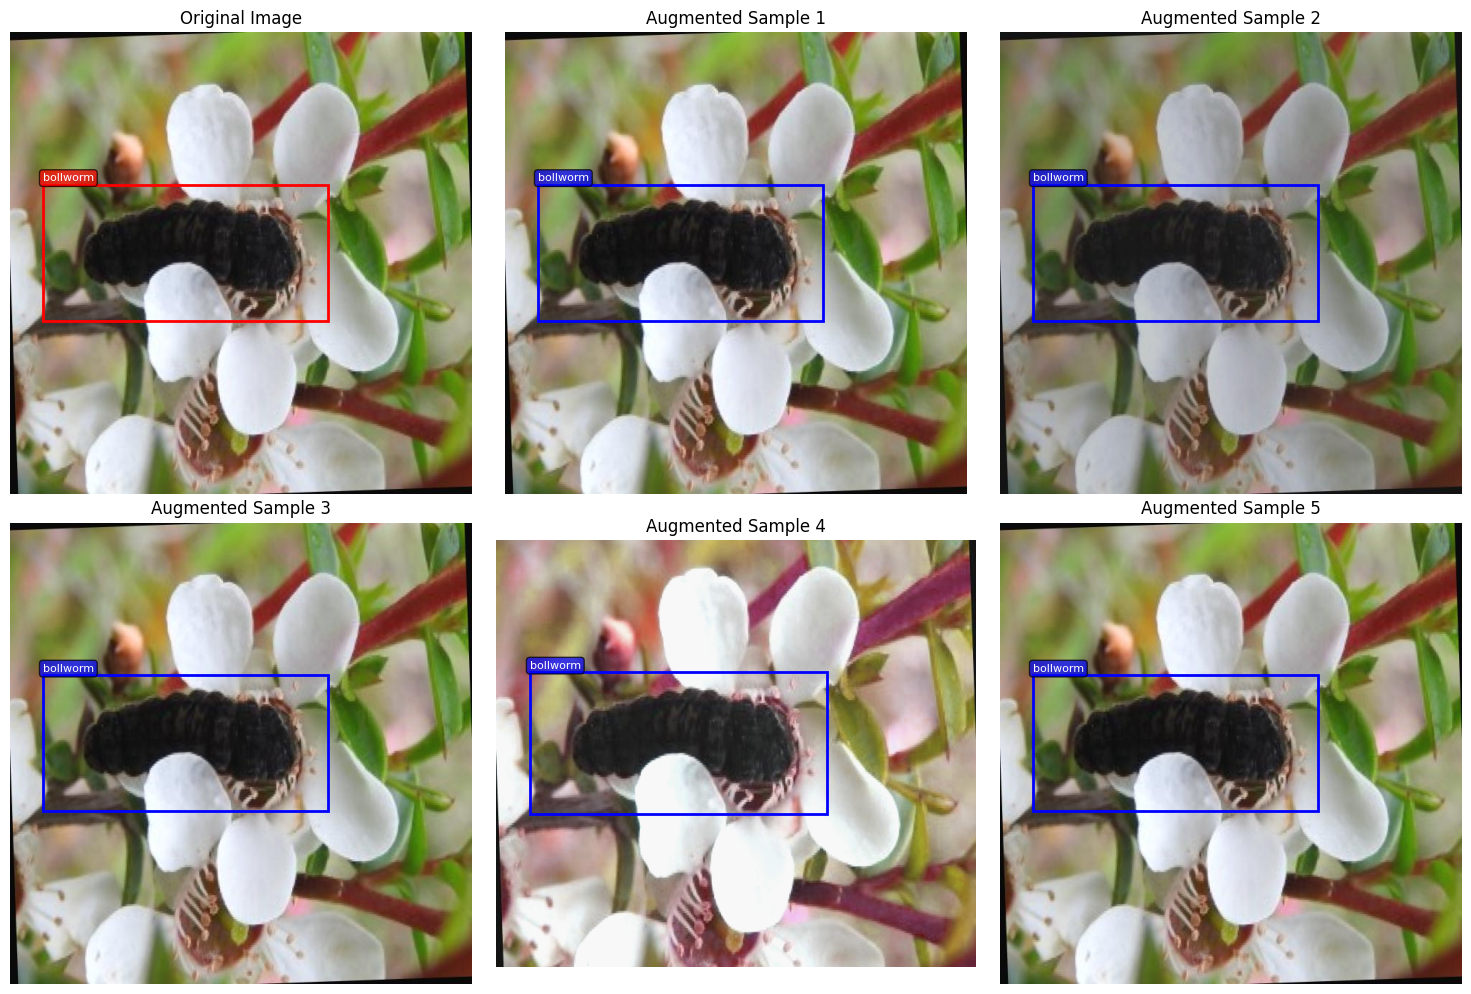

In [25]:
print("data enhancement")
import random
import numpy as np
from PIL import Image
image_files = [f for f in os.listdir(train_images_dir) if f.endswith(('.jpg', '.png'))]
if image_files:
    sample_image_file = random.choice(image_files)
    sample_image_path = os.path.join(train_images_dir, sample_image_file)
    sample_label_path = os.path.join(train_images_dir.replace('images', 'labels'),
                                    sample_image_file.replace('.jpg', '.txt').replace('.png', '.txt'))


    image = Image.open(sample_image_path).convert('RGB')
    boxes = []
    labels = []
    if os.path.exists(sample_label_path):
        with open(sample_label_path, 'r') as f:
            for line in f:
                data = line.strip().split()
                if len(data) == 5:
                    class_id = int(data[0])
                    x_center = float(data[1])
                    y_center = float(data[2])
                    width = float(data[3])
                    height = float(data[4])
                    boxes.append([x_center, y_center, width, height])
                    labels.append(class_id)

    boxes = np.array(boxes)
    labels = np.array(labels)

    print(f"Visualizing the effect of data augmentation: {sample_image_file}")
    print(f"Number of bounding boxes: {len(boxes)}")
    visualize_augmentations(image, boxes, labels, config.CLASS_NAMES)

In [26]:
from config import config
from model import MobileNetFeatureYOLOv8
from trainer import PestTrainer
config.BATCH_SIZE = 16
config.NUM_WORKERS = 4
config.IMAGE_SIZE = 640

print(f"修改后的配置:")
print(f"BATCH_SIZE: {config.BATCH_SIZE}")
print(f"NUM_WORKERS: {config.NUM_WORKERS}")
print(f"IMAGE_SIZE: {config.IMAGE_SIZE}")


修改后的配置:
BATCH_SIZE: 16
NUM_WORKERS: 4
IMAGE_SIZE: 640


In [27]:
model_creator = MobileNetFeatureYOLOv8(config)
model = model_creator.get_model()

Load the pre-trained YOLOv8 model.
Change the number of categories to: 12
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 110MB/s]


MobileNet特征提取器已冻结

WARNING ⚠️ torch.Tensor inputs should be normalized 0.0-1.0 but max value is 4.772307395935059. Dividing input by 255.
0: 640x640 (no detections), 9.3ms
Speed: 1.4ms preprocess, 9.3ms inference, 20.1ms postprocess per image at shape (1, 3, 640, 640)
获取YOLO通道数失败: 'Results' object has no attribute 'shape'. See valid attributes below.
A class for storing and manipulating inference results.

    This class provides comprehensive functionality for handling inference results from various Ultralytics models,
    including detection, segmentation, classification, and pose estimation. It supports visualization, data export, and
    various coordinate transformations.

    Attributes:
        orig_img (np.ndarray): The original image as a numpy array.
        orig_shape (tuple[int, int]): Original image shape in (height, width) format.
        boxes (Boxes | None): Detected bounding boxes.
        masks (Masks | None): Segmentation masks.
        probs (Probs | None): Classifi

In [28]:
trainer = PestTrainer(config, model, data_yaml_path)

In [32]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
model.model.nc = 12

results = model.train(
    data='/content/AgroPest-12/data.yaml',
    epochs=10,
    imgsz=640,
    batch=16,
    workers=2,
    device='0',
    project='/content/output',
    name='mobilenet_small_train_fixed',
    exist_ok=True,
    plots=False
)

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.9.1+cu128 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/AgroPest-12/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=mobilenet_small_train_fixed, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.9.1+cu128 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,007,988 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1641.7±539.5 MB/s, size: 39.1 KB)
val: Scanning /content/AgroPest-12/valid/labels.cache... 1095 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1095/1095 2.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 7.2it/s 9.6s
                   all       1095       1341       0.82      0.662      0.733      0.431
                 aphid         96        178      0.854      0.559      0.667      0.262
              armyworm         99        110       0.78        0.8      0.835       0.38
                beetle         89        100      0.558      0.517      0.508      0.261
              bollworm         77        139      0.768      0.403      0.472      0.238
           grasshopper         53         7

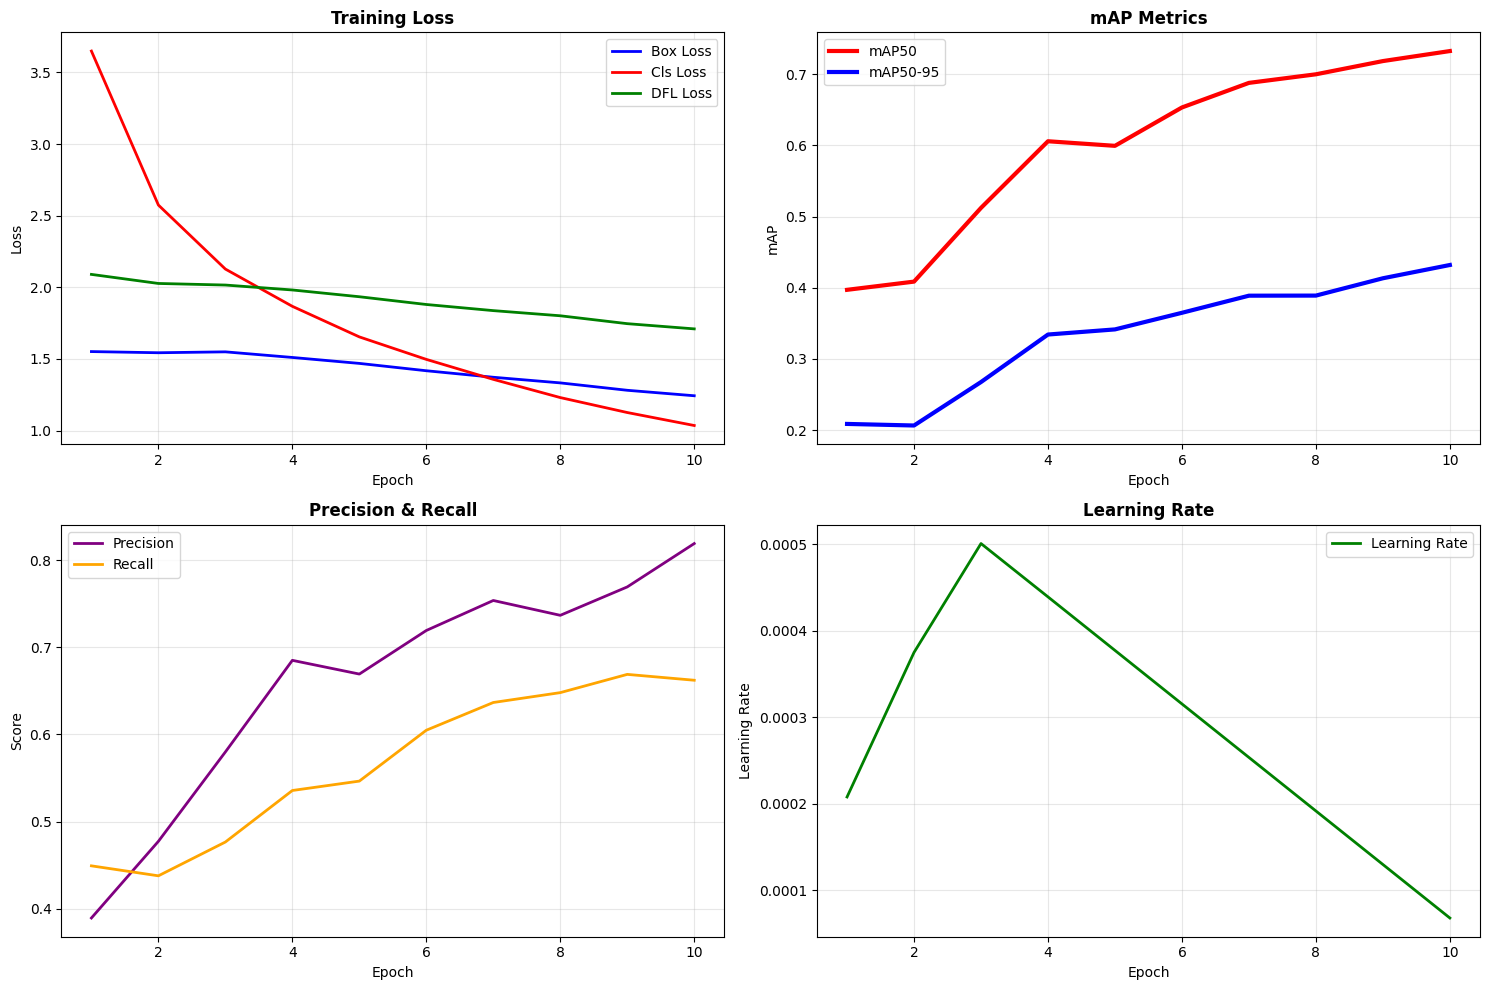


image 1/1 /content/AgroPest-12/valid/images/Weevil-224-_jpg.rf.0b3535088e2d861ae6badc704266eb1d.jpg: 640x640 1 weevil, 7.4ms
Speed: 1.8ms preprocess, 7.4ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/AgroPest-12/valid/images/moth-417-_jpg.rf.fbf0f2a93bc15df080484267b9957240.jpg: 640x640 1 sawfly, 7.3ms
Speed: 1.5ms preprocess, 7.3ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/AgroPest-12/valid/images/grasshopper-209-_jpg.rf.661bd700fee31c2282445d119edfa8cb.jpg: 640x640 1 mosquito, 7.5ms
Speed: 2.9ms preprocess, 7.5ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/AgroPest-12/valid/images/bees-283-_jpg.rf.31e746390379632bb6d611fffad88d34.jpg: 640x640 1 armyworm, 7.4ms
Speed: 2.9ms preprocess, 7.4ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/AgroPest-12/valid/images/snail-271-_jpg.rf.8dd5cdc966ed7cb8721ac3eb77be04d8.jpg: 640x64

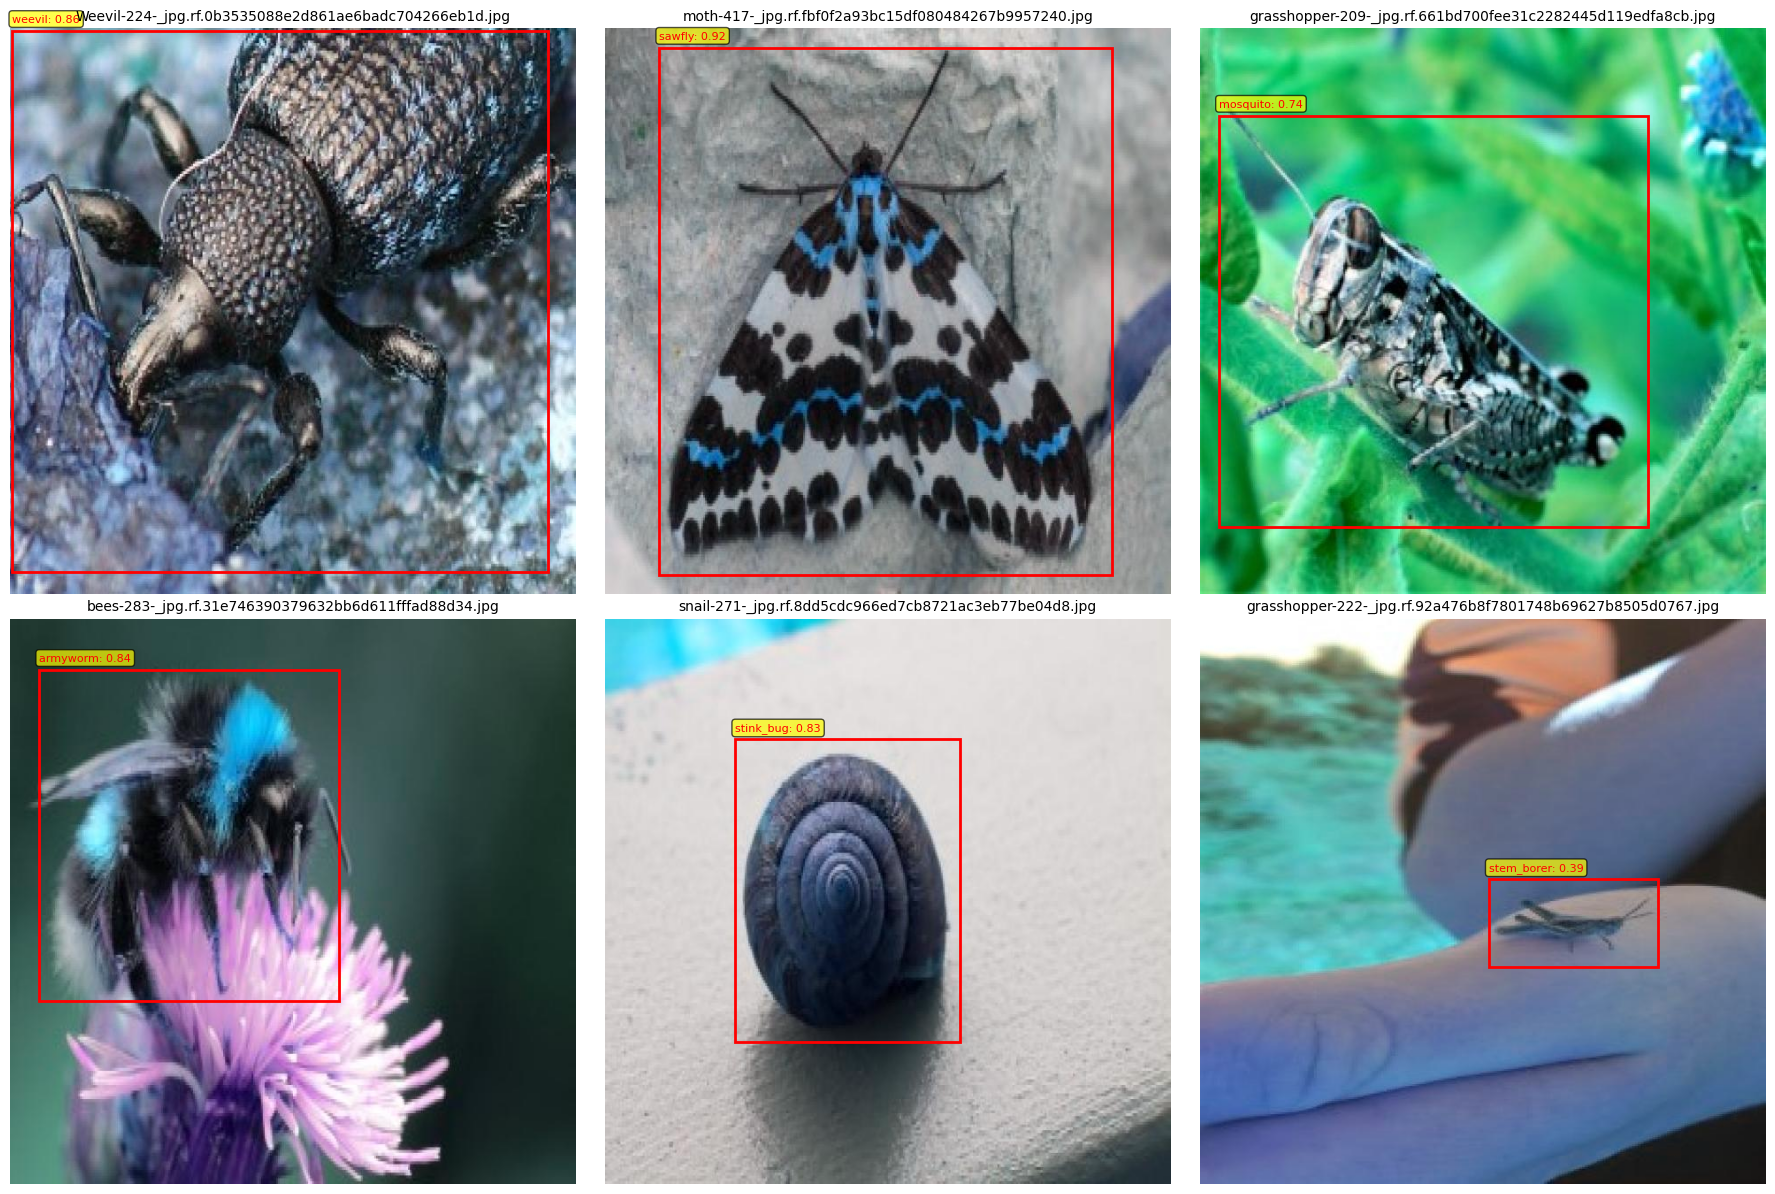

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from ultralytics import YOLO

def manual_visual_evaluation_fixed():
    model_path = "/content/output/mobilenet_small_train_fixed/weights/best.pt"
    model = YOLO(model_path)
    results = model.val(
        data='/content/AgroPest-12/data.yaml',
        imgsz=640,
        batch=16,
        device='0',
        plots=False,
        save_json=False
    )
    print("\n" + "="*60)
    if hasattr(results, 'box'):
        metrics = results.box
        map50 = metrics.map50
        map50_95 = metrics.map
        precision = metrics.p
        recall = metrics.r

        if hasattr(map50, '__len__') and len(map50) > 0:
            map50 = map50[0]
        if hasattr(map50_95, '__len__') and len(map50_95) > 0:
            map50_95 = map50_95[0]
        if hasattr(precision, '__len__') and len(precision) > 0:
            precision = precision[0]
        if hasattr(recall, '__len__') and len(recall) > 0:
            recall = recall[0]

        print(f"mAP50:     {float(map50):.4f}")
        print(f"mAP50-95:  {float(map50_95):.4f}")
        print(f"precision:    {float(precision):.4f}")
        print(f"recall:    {float(recall):.4f}")
    else:
        print("fail")

    print("="*60)
    plot_training_curves_manual_fixed()
    plot_predictions_manual_fixed(model)

    return results

def plot_training_curves_manual_fixed():
    try:
        results_csv = '/content/output/mobilenet_small_train_fixed/results.csv'
        if os.path.exists(results_csv):
            df = pd.read_csv(results_csv)
            fig, axes = plt.subplots(2, 2, figsize=(15, 10))

            if 'train/box_loss' in df.columns:
                axes[0,0].plot(df['epoch'], df['train/box_loss'], 'b-', label='Box Loss', linewidth=2)
                axes[0,0].plot(df['epoch'], df['train/cls_loss'], 'r-', label='Cls Loss', linewidth=2)
                axes[0,0].plot(df['epoch'], df['train/dfl_loss'], 'g-', label='DFL Loss', linewidth=2)
                axes[0,0].set_title('Training Loss', fontweight='bold', fontsize=12)
                axes[0,0].set_xlabel('Epoch')
                axes[0,0].set_ylabel('Loss')
                axes[0,0].legend()
                axes[0,0].grid(True, alpha=0.3)

            if 'metrics/mAP50(B)' in df.columns:
                axes[0,1].plot(df['epoch'], df['metrics/mAP50(B)'], 'r-', label='mAP50', linewidth=3)
                axes[0,1].plot(df['epoch'], df['metrics/mAP50-95(B)'], 'b-', label='mAP50-95', linewidth=3)
                axes[0,1].set_title('mAP Metrics', fontweight='bold', fontsize=12)
                axes[0,1].set_xlabel('Epoch')
                axes[0,1].set_ylabel('mAP')
                axes[0,1].legend()
                axes[0,1].grid(True, alpha=0.3)

            if 'metrics/precision(B)' in df.columns:
                axes[1,0].plot(df['epoch'], df['metrics/precision(B)'], 'purple', label='Precision', linewidth=2)
                axes[1,0].plot(df['epoch'], df['metrics/recall(B)'], 'orange', label='Recall', linewidth=2)
                axes[1,0].set_title('Precision & Recall', fontweight='bold', fontsize=12)
                axes[1,0].set_xlabel('Epoch')
                axes[1,0].set_ylabel('Score')
                axes[1,0].legend()
                axes[1,0].grid(True, alpha=0.3)

            if 'lr/pg0' in df.columns:
                axes[1,1].plot(df['epoch'], df['lr/pg0'], 'green', label='Learning Rate', linewidth=2)
                axes[1,1].set_title('Learning Rate', fontweight='bold', fontsize=12)
                axes[1,1].set_xlabel('Epoch')
                axes[1,1].set_ylabel('Learning Rate')
                axes[1,1].legend()
                axes[1,1].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.savefig('/content/training_curves_fixed.png', dpi=300, bbox_inches='tight')
            plt.show()
        else:
            print("fail")

    except Exception as e:
        print(f"fail")

def plot_predictions_manual_fixed(model, num_examples=6):
    try:
        val_images_dir = '/content/AgroPest-12/valid/images'
        if os.path.exists(val_images_dir):
            image_files = [f for f in os.listdir(val_images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]
            selected_images = image_files[:num_examples]

            if selected_images:
                fig, axes = plt.subplots(2, 3, figsize=(18, 12))
                axes = axes.flatten()

                for i, img_file in enumerate(selected_images):
                    if i >= len(axes):
                        break

                    img_path = os.path.join(val_images_dir, img_file)
                    results = model.predict(
                        source=img_path,
                        imgsz=640,
                        conf=0.25,
                        device='0',
                        save=False,
                        save_txt=False
                    )
                    for r in results:
                        orig_img = r.orig_img
                        axes[i].imshow(orig_img)
                        if len(r.boxes) > 0:
                            for box in r.boxes:
                                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                                conf = box.conf[0].cpu().numpy()
                                cls = int(box.cls[0].cpu().numpy())
                                rect = plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                                   fill=False, edgecolor='red', linewidth=2)
                                axes[i].add_patch(rect)
                                label = f"{model.model.names[cls]}: {conf:.2f}"
                                axes[i].text(x1, y1-10, label, color='red', fontsize=8,
                                           bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.7))

                        axes[i].set_title(f'{img_file}', fontsize=10)
                        axes[i].axis('off')
                        break

                plt.tight_layout()
                plt.savefig('/content/prediction_examples_fixed.png', dpi=300, bbox_inches='tight')
                plt.show()
        else:
            print("fail")

    except Exception as e:
        print(f"fail: {e}")
results = manual_visual_evaluation_fixed()